In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [66]:
R_gen = 1.3 #ohm
R_mot = 3.8 #ohm
phi_0 = 0.06 #Wb
U_ent = np.array([6.78,11.7,19.11,24.8]) #V
I_ent = np.array([0.99,1.26,1.62,1.9]) #A
U_sort = np.array([4.75,9.03, 15.3, 20.2]) #V
I_sort = np.array([0.146, 0.27, 0.47, 0.62]) #A
Omega = np.array([775,1476, 2520, 3336]) #tr/min
P_e = np.array([6.7, 14.7, 30.9, 45.54]) # W
P_s = np.array([0.68, 2.5, 7.2, 12.4]) # W
Pperte_tot = P_e - P_s # W
P_cuiv_mot = R_mot * I_ent**2 # W
P_cuiv_gen = R_gen * I_sort**2 # W
P_perte_meca = Pperte_tot - P_cuiv_mot - P_cuiv_gen # W
efficiency = P_s / P_e 
couple_utile = ((U_sort * I_sort)+R_gen * I_sort**2 + P_perte_meca/2) / (Omega * (2 * np.pi / 60)) # Nm

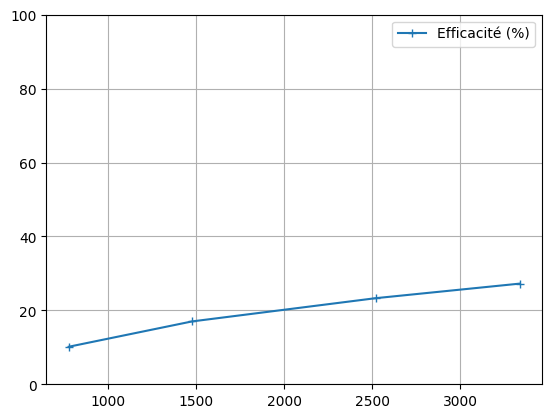

In [4]:
plt.plot(Omega, efficiency * 100, marker='+', label='Efficacité (%)')
plt.grid()
plt.ylim(0, 100)
plt.legend()


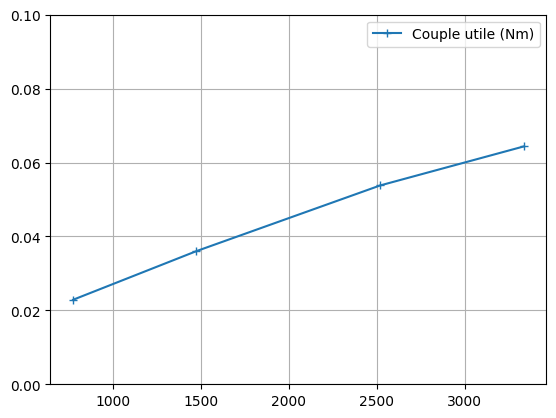

In [5]:
plt.plot(Omega, couple_utile, marker='+', label='Couple utile (Nm)')
plt.grid()
plt.ylim(0, 0.1)
plt.legend()

In [305]:
T1,I1,T2,V1 = np.loadtxt("15mm_12V.csv", delimiter=";",skiprows=1, unpack=True)

In [306]:
## fonction lissage : retourne un tableau correspondant aux valeurs de signal_brut remplacées par une moyenne glissante, des valeurs qui les entourent, centrée de largeur deux L
def lisser(signal_brut,L):
    res = np.copy(signal_brut) # duplication des valeurs
    for i in range (1,len(signal_brut)-1): # toutes les valeurs sauf la première et la dernière
        L_g = min(i,L) # nombre de valeurs disponibles à gauche
        L_d = min(len(signal_brut)-i-1,L) # nombre de valeurs disponibles à droite
        Li=min(L_g,L_d)
        res[i]=np.sum(signal_brut[i-Li:i+Li+1])/(2*Li+1)
    return res

In [307]:
#n=303 # nombre de points à lisser 10mm
#n=500 # nombre de points à lisser 11,4mm
#n=475 # nombre de points à lisser 13,5mm
n=403 # nombre de points à lisser 14mm
#n=403 # nombre de points à lisser 15mm
Tension_liss = lisser(V1[:n],30)

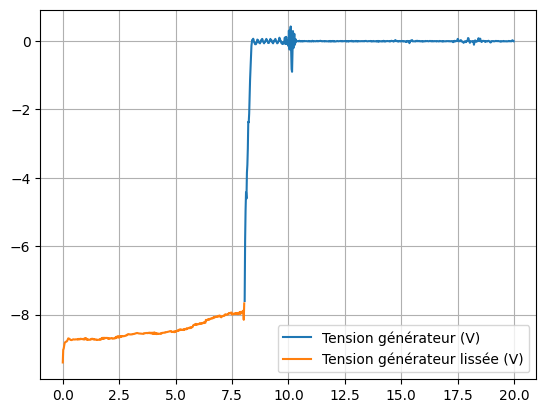

In [308]:
plt.plot(T2[n:],V1[n:], label='Tension générateur (V)')
plt.plot(T2[:n], Tension_liss, label='Tension générateur lissée (V)')
plt.legend()
plt.grid()

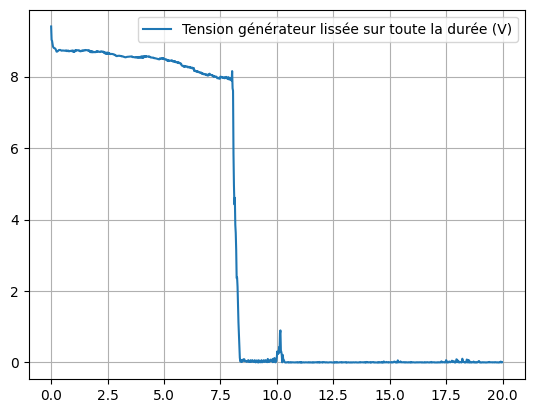

In [309]:
Tension_fin = np.concatenate((np.abs(Tension_liss), np.abs(V1[n:])), axis=0)
plt.plot(T2,Tension_fin, label='Tension générateur lissée sur toute la durée (V)')
plt.grid()
plt.legend()

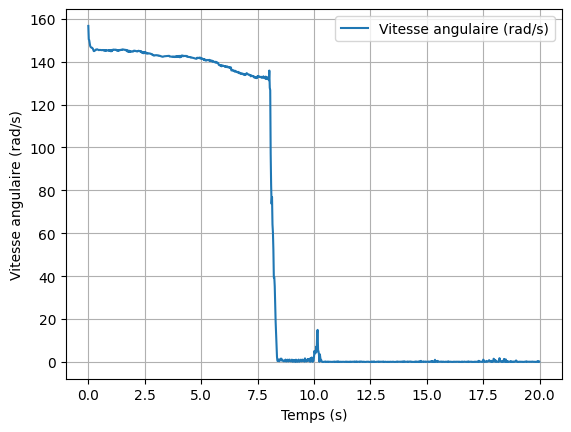

In [310]:
Omega = Tension_fin / phi_0
plt.plot(T2, Omega, label='Vitesse angulaire (rad/s)')
plt.xlabel('Temps (s)')
plt.ylabel('Vitesse angulaire (rad/s)')
plt.grid()
plt.legend()

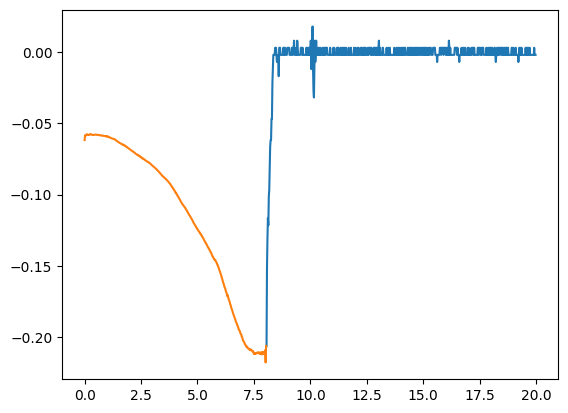

In [311]:
Intensite_liss = lisser(I1[:n],30)
plt.plot(T2[n:],I1[n:], label='Courant générateur (A)')
plt.plot(T2[:n], Intensite_liss, label='Courant générateur lissé (A)')

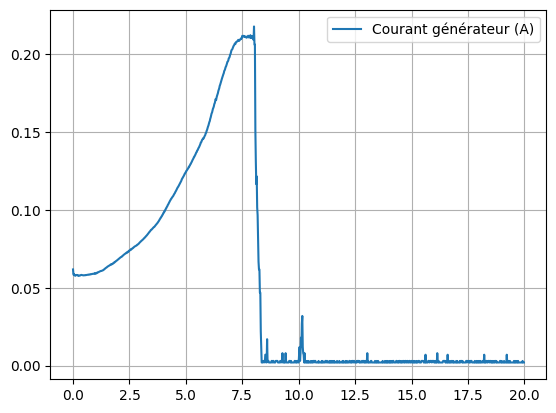

In [312]:
Intensite_fin = np.concatenate((np.abs(Intensite_liss), np.abs(I1[n:])), axis=0)
plt.plot(T2, Intensite_fin, label='Courant générateur (A)')

plt.grid()
plt.legend()


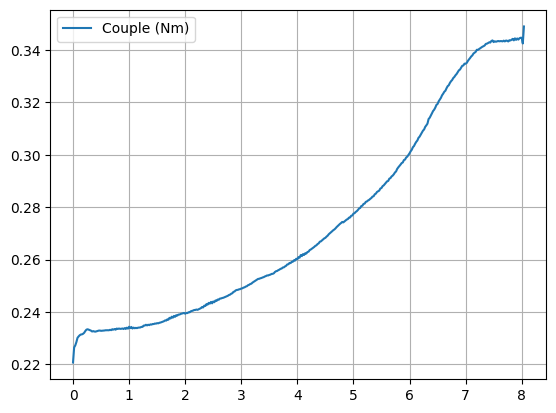

In [313]:
Cpl = ((Tension_fin[:n] * Intensite_fin[:n])+R_gen * Intensite_fin[:n]**2 + P_perte_meca[1]/2) / (Omega[:n] * (2 * np.pi / 60))
plt.plot(T2[:n], Cpl, label='Couple (Nm)')

plt.grid()
plt.legend()

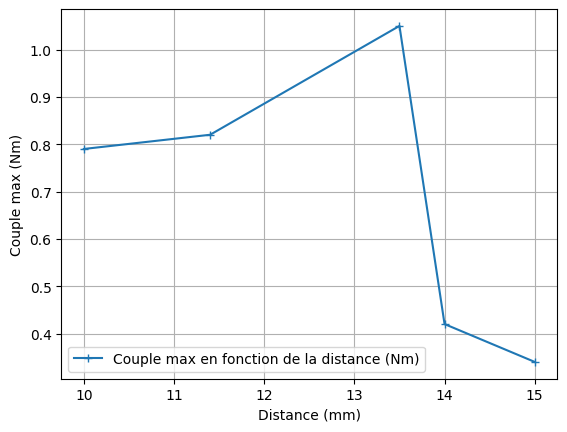

In [315]:
d = [10,11.4,13.5,14,15] # mm
C_max = [0.79, 0.82, 1.05, 0.42, 0.34] # Nm
plt.plot(d, C_max, marker='+', label='Couple max en fonction de la distance (Nm)')
plt.xlabel('Distance (mm)')
plt.ylabel('Couple max (Nm)')
plt.grid()
plt.legend()